#  Scientfic Computing

Material of the course Scientific Computing, Instituto Tecnológico Metropolitano.

Author: Sebastián Roldán Vasco


---


# Advanced data analysis

Advanced data manipulation with Pandas is a crucial skill for efficiently working with large and complex datasets in Python. In this context, "advanced" refers to techniques and operations that go beyond the basic use of the libraries, e.g. Pandas. These advanced techniques typically involve more complex and sophisticated methods to transform, analyze, and manage data effectively.

In this notebook, we will explore some advance techniques for data manipulation with Pandas.


In [ ]:
# Import and install  the necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder

## Application of custom functions

There are two main methods to apply a funtion over a Pandas object: `apply()` and `map()`:



| Feature | `apply()` | `map()` |
|----------|------------|---------|
| **Used On** | DataFrame or Series | Series only |
| **Purpose** | Apply a function along an axis (rows or columns) of a DataFrame, or on each element of a Series | Apply a function or mapping elementwise of a Series |
| **Input Function Type** | Accepts any Python function, lambda, or NumPy function | Accepts a function, dictionary, or Series |
| **Axis Parameter** | Yes (`axis=0` for columns, `axis=1` for rows) | No |
| **Flexibility** | More general and flexible | Simpler and faster for element-wise transformations |
| **Return Type** | Can return Series, DataFrame, or scalar (depending on function) | Always returns a Series |
| **Performance** | Slower (more overhead, works with entire DataFrame) | Faster for simple element-wise operations |
| **Example (Series)** | ```df['col'].apply(lambda x: x ** 2) ``` | ```df['col'].map(lambda x: x ** 2) ``` |
| **Example (DataFrame)** | ```df.apply(np.sum, axis=0)  # sum columns ``` |  Not applicable (works only on Series) |
| **Can Handle Dictionaries / Series as Input?** |  Yes, if used cleverly in functions |  Yes, directly supports mapping dicts or Series |


In [ ]:
# Create a numerical DataFrame




In [ ]:
# Define a custom function
def my_func(x):
    return ...

In [ ]:
# Compare the use of map and apply



## Group operations





The `groupby()` function in pandas is used to:
- Split data into groups: Divide your data into groups based on one or more keys (columns)
- Apply operations: Apply a function to each group independently (e.g., `mean`, `sum`, `count`)
- Combine the results: Merge the results back into a new DataFrame or Series

This process allows you to easily calculate **group-wise statistics** with `agg()` or perform **grouped transformations** with `transform()`

Syntax:

```python
df.groupby(by=None, axis=0, as_index=True, sort=True)
```


| Feature | `transform()` | `agg()` (Aggregate) |
|----------|----------------|--------------------|
| **Used On** | DataFrame or Series | DataFrame or Series |
| **Purpose** | Returns a **transformed object** with the **same shape** as the input | Returns a **reduced/aggregated result** (often smaller in shape) |
| **Output Shape** | Same as input | Often smaller (depends on aggregation) |
| **Return Type** | Series or DataFrame (same size as input) | Scalar, Series, or DataFrame (reduced) |
| **Function Type** | Element-wise or group-wise transformation | Aggregation (summary/statistical functions) |
| **Multiple Functions Allowed** |  Yes (returns DataFrame of same size) |  Yes (returns multiple aggregated results) |
| **Supports GroupBy?** |  Yes |  Yes |
| **Common Use Case** | Apply a function and keep original structure (e.g. normalize, scale, fill missing values) | Summarize data (e.g. mean, sum, count) |
| **Can Use Custom Functions?** |  Yes |  Yes |
| **Preserves Original Index?** |  Yes |  Not necessarily (depends on aggregation) |
| **Example (Series)** | ```df['A'].transform(lambda x: x - x.mean()) ``` | ``` df['A'].agg(['mean', 'sum']) ``` |
| **Example (GroupBy)** | ``` df.groupby('key')['value'].transform('mean') ``` | ``` df.groupby('key')['value'].agg('mean') ``` |
| **Shape Difference Example** | Same as input | Reduced / summarized output |


### Groupby and aggregation

Aggregate using one or more operations over the specified axis. Aggregation is performed according to Numpy functions, e.g. mean, min, max, std, etc., as well as by anonymous functions.

In [ ]:
# Create a DataFrame continents, countries and GDP



In [ ]:
# Group by column 'Continent' and calculate the minimum with agg



In [ ]:
# Find the mean by continent. Don't use agg

### Transformations with `groupby`

Call function producing a same-indexed Series on each group.

Returns a Series having the same indexes as the original object filled with the transformed values.

In [ ]:
# Group by column 'Continent' and add antoher column with the mean by transform



Summary of methods:

| Task                                        | Function      |
| ------------------------------------------- | ------------- |
| Element-wise change to one column           | `map()`       |
| Row/column-wise operation on full DataFrame | `apply()`     |
| Group-wise transformation (same shape)      | `transform()` |
| Group-wise aggregation (reduced shape)      | `agg()`       |


---

## Data normalization

One common application is the data normalization. For example, lets consider the normalization by the standard score:

$X_{norm}=\frac{X-\mu}{\sigma}$,

where $\mu$ and $\sigma$ are the mean and the standard deviation of $X$, respectively

In [ ]:
# Number of samples
n_samples = 1000

# Generate normal data for two columns in a DataFrame


# Create a DataFrame



In [ ]:
# Visualize the corresponding KDE plot

In [ ]:
# Apply a normalization with a lambda function. Use the transform method directly


In [ ]:
# Visualize the KDE plot of the normalized DataFrame

## Handling missing data

Missing data, also known as missing values, refers to the absence of data points in a dataset. This can occur for various reasons such as data collection errors, non-responses in surveys, data corruption, or simply because the information was not available.


Handling missing data is a crucial step in data preprocessing and analysis because it can significantly affect the results and performance of machine learning models.

**Types of Missing Data**
- Missing Completely at Random (MCAR): the missingness is entirely random and not related to any observed or unobserved data.
\begin{equation}
p(\text{missing})=\text{constant}
\end{equation}

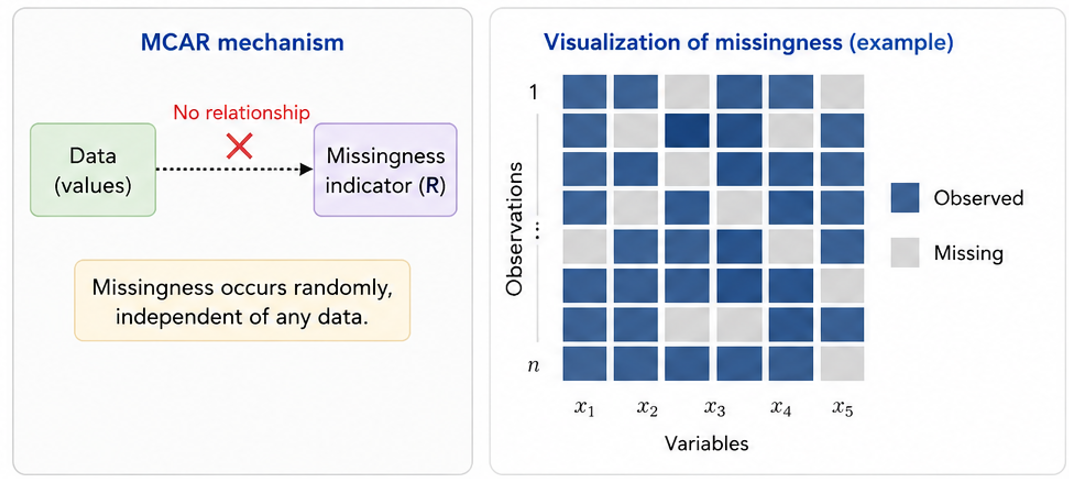

*Example*: A survey respondent accidentally skips a question.

- Missing at Random (MAR): the missingness is related to some of the observed data but not to the missing data itself.

Given the observed variables $X_1$, $X_3$ and $Y$, the variable with unobserved values $X_2$ and the missingness indicator $R_2$ (1 when missing, 0 when observed), the mathematical formulation can be written as follows:

\begin{equation}
p(R_2=1|X_1, X_3, Y, X_2)=p(R_2=1|X_1, X_3, Y)
\end{equation}


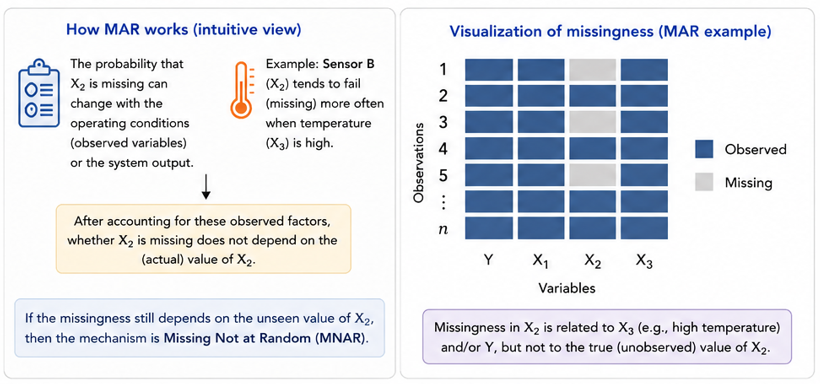


*Example*: Income data might be missing more often for people with higher education levels.

- Missing Not at Random (MNAR): the missingness is related to the value of the missing data itself.

The mathematical formulation can be written as follows:

\begin{equation}
p(R_2=1|X_1, X_3, Y, X_2)\neq p(R_2=1|X_1, X_3, Y)
\end{equation}


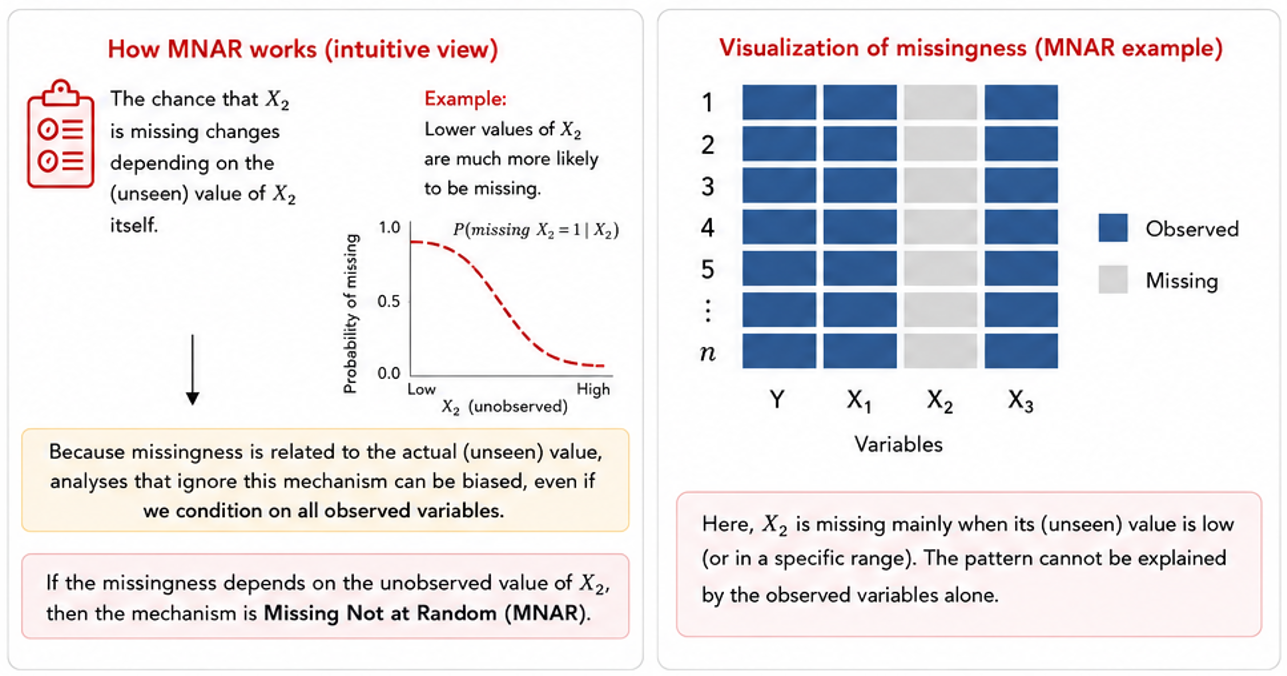

*Example*: People with very high incomes might choose not to disclose their income.

Handling missing data in Python is straigthforward by the Pandas features.

In [ ]:
# Create a DataFrame with missing values




In [ ]:
# Find the number of missing data

In general, we can perform three kind of processes with missing data:

- Removal



```python
df.dropna()  # Drop rows with any missing values
df.dropna(axis=1)  # Drop columns with any missing values
df.dropna(subset=['A', 'C'])  # Drop rows where specific columns have missing values

```

We must check the `inplace` method to update the DataFrame.


- Imputation

We can fill the missing values with specific numbers, or with the meand, the median, etc. of the known values



```python
df.fillna(0)  # Fill all missing values with 0
df['A'].fillna(df['A'].mean())  # Fill missing values in column 'A' with the column mean
```




- Interpolation

Similar to the imputation. it is intended to fill the missing values by  interpolating between known values.

## Data merging and joining

In [ ]:
data1 = {
    'key1': ['A', 'B', 'C'],
    'key2': ['X', 'Y', 'Z'],
    'value1': [1, 2, 3]
}

df1 = pd.DataFrame(data1)
print("df1:")
print(df1)


data2 = {
    'key1': ['A', 'B', 'D'],
    'key2': ['X', 'W', 'Y'],
    'value2': [4, 5, 6]
}

df2 = pd.DataFrame(data2)
print("\ndf2:")
print(df2)


In [ ]:
# Search for the merge() documentation

## MultiIndex and MultiColumn DataFrames

MultiIndex and MultiColumn DataFrames in pandas allow for hierarchical indexing along rows and columns, respectively. This enables you to represent and work with higher-dimensional data structures efficiently.



### MultiIndex DataFrame

- Each level of the MultiIndex represents a different level of hierarchy.
- We can access data using tuples representing the indices at each level.


If you want to convert a column into a new index, you can use the following syntax:



```python
df = df.set_index('column_name')
```



In [ ]:
# In the latter example, we can make that `key1` and `key2` be the new indexes:

How to access to any datum in this DataFrame which has more than one index?

In general, indexes are accessed within tuples inside the brackets, e.g.

```python
df.loc[(name of index 1, name of index 2), name of columns]
```

But there are several ways to do so:

In [ ]:
# Using loc



# Using iloc



If you want to access a single one value, you can also use `.at` or `.iat()`. They are similar to `loc` and `iloc` but:
- `at` and `iat` are faster than `loc` and `iloc`, respectively
- `at` and `iat` do not allow slicing

In [ ]:
# Using at



# Using iat


In [ ]:
# Access an entire row


In [ ]:
# Access an entire column


The general pattern for Multiindex and MultiColumn filtering is as follows:



```python
df[
    (df.index.get_level_values('level_name') == some_value) &
    (df[(col_level1, col_level2)] condition)
    ]
```




In [ ]:
# Accessing by conditional filtering


Another example:

In [ ]:
# Create a sample DataFrame with MultiIndex directly
data = {
    ('2022', 'Jan'): [100, 200],
    ('2022', 'Feb'): [150, 250],
    ('2023', 'Jan'): [180, 220],
    ('2023', 'Feb'): [160, 240]
}
index = pd.MultiIndex.from_tuples([('Product A', 'Region 1'), ('Product B', 'Region 2')], names=['Product', 'Region'])
df_multiindex = pd.DataFrame(data, index=index)

print("MultiIndex DataFrame:")
df_multiindex

### MultiColumn DataFrame

- Each level of the MultiColumn represents a different level of hierarchy for columns.
- We can access data using tuples representing the columns at each level.

In [ ]:
data.keys()

In [ ]:
columns = pd.MultiIndex.from_tuples(data.keys())
df_multicolumn = pd.DataFrame(data, columns=columns)

print("MultiColumn DataFrame:")
df_multicolumn

In [ ]:
# Try indexing

## Categorical data

Categorical data types in pandas are particularly useful when dealing with data columns that have a limited number of unique values, for instance grades, gender, blood group type, etc. They offer benefits in terms of both memory and performance optimization. Additionally, this strategy provides semantic meaning.




*Urinary diseases example:*

It will be the example of diagnosing of the [acute inflammations of urinary bladder and acute nephritises](https://archive.ics.uci.edu/dataset/184/acute+inflammations).

- Acute inflammation of the urinary bladder is characterized by the sudden onset of abdominal pain and frequent, painful urination, sometimes accompanied by urinary incontinence. The body temperature may rise, but usually not above 38°C. The urine is often cloudy and sometimes bloody. With appropriate treatment, symptoms typically subside within a few days, but there is a tendency for recurrence. Individuals with acute inflammation of the urinary bladder are at risk of developing a chronic form of the illness.

- Acute nephritis, originating from the renal pelvis, is significantly more common in women than in men. It begins with a sudden high fever, often reaching or exceeding 40°C, accompanied by chills and severe pain on one or both sides of the lower back. Symptoms of acute inflammation of the urinary bladder frequently appear as well. Nausea, vomiting, and widespread abdominal pain are also common.

This data was compiled by a medical expert to create a dataset for testing an expert system designed to diagnose two urinary system diseases. Data is organized as follows:

  -- Attribute lines:
       For example, '35,9	no	no	yes	yes	yes	yes	no'
       Where:

	 '35,9'	Temperature of patient
	 'no'	Occurrence of nausea
	 'no'	Lumbar pain
	 'yes'	Urine pushing (continuous need for urination)
	 'yes'	Micturition pains  
	 'yes'	Burning of urethra, itch, swelling of urethra outlet
	 'yes'	decision: Inflammation of urinary bladder  
	 'no'	decision: Nephritis of renal pelvis origin

In [ ]:
# fetch dataset
acute_inflammations = fetch_ucirepo(id=184)

# data (as pandas dataframes)
X = acute_inflammations.data.features
y = acute_inflammations.data.targets

# metadata
print(acute_inflammations.metadata)
print('\n\n\n')
# variable information
print(acute_inflammations.variables)


In [ ]:
print(type(X))
X

In [ ]:
print("\nOriginal Data Types:")
print(...)

### Converting to category type

Observe that the first column is ordinal, but the remaining are categorical Notwihtstanding, we must convert them to the type ```category```



In [ ]:
categorical_columns = X.columns[1:].to_list()
categorical_columns

In [ ]:
X[categorical_columns] = X[categorical_columns].astype('category')
print("\nConverted Data Types:")
print(X.dtypes)

Observe that the type of each datum was not changed (`str`), but the entire columns was modified instead (`object` to `category`).

Now, lets analyze the diseases:

In [ ]:
y

Note that `y` is completely categorical, and we can handle it accordingly:

In [ ]:
y = y.astype('category')
print(y.dtypes)

### One-hot encoding

This technique is very useful in the field of machine learning. It converts categorical data to a new numerical format, as follows:

In [ ]:
y_oh = pd.get_dummies(y)
y_oh

However, this representation has drawbacks to feed numerical models. Thus, it is important to convert into a numerical format of zeros and ones:

In [ ]:
y_oh = y_oh.astype(int)
y_oh

### Label encoding

This process is similar to the one-hot encoding, but both processes have key differential features:

- **Label encoding**:
  - Assigns a unique integer label to each category.
  - Used for **ordinal categorical variables** with a natural order.
  - Results in a single integer column, potentially more memory-efficient.

- **One-hot encoding**:
  - Each category gets a separate binary column.
  - Used for **nominal categorical variables** with no inherent order.
  - Results in a sparse matrix and increases dimensionality.

In [ ]:
label_encoder = LabelEncoder()

y_le= label_encoder.fit_transform(y['nephritis']) # This accepts 1D arrays only
y_le

### Custom mapping

The mapping defines a specific relationship between original categorical values and their corresponding numerical or categorical representations. Instead of label or one-hot encoding, custom mapping allows the definition of custom rules for transforming categorical data.

You can use `map()` over a specific column, and a dictionary within with the new rules

In [ ]:
# Custom mapping
mapping = {'yes': 'Consider medication', 'no': 'Check bladder inflamation'}

# Apply the mapping


In [ ]:
print(y.dtypes)

## Performance Optimization


Pandas provides various techniques for optimizing performance, such as using Cython-based extensions (cython and numba), utilizing dtype optimization, and using chunksize parameter for handling large datasets.

### Cython-based extensions

Cython is a programming language that makes writing C extensions for the Python language as easy as Python itself. It aims to become a superset of the Python language, which gives it high-level, object-oriented, functional, and dynamic programming capabilities.

It supports calling C functions and declaring C types on variables and class attributes. The compiler generates efficient C code from Cython code, which compiles with major C/C++ compilers in CPython.

*Code example:*

```
%load_ext Cython

# Define a function using Cython
%%cython
def cython_sum(int n):
    cdef int i
    cdef int s = 0
    for i in range(n):
        s += i
    return s

# Use the function in pandas
df = pd.DataFrame(np.random.randn(1000, 1000))
df.apply(cython_sum)
```



### Numba

Numba is a just-in-time compiler for Python that translates Python functions to optimized machine code using LLVM. It's particularly useful for speeding up numerical computations.

*Code example:*



```
from numba import njit

# Define a function using Numba
@njit
def numba_sum(arr):
    s = 0
    for i in range(len(arr)):
        s += arr[i]
    return s

# Use the function in pandas
df = pd.DataFrame(np.random.randn(1000, 1000))
df.apply(numba_sum)
```



Unfortunately, Colab has limitations for using Cython and Numba.

### Dtype optimization

Pandas allows you to specify the data types of columns explicitly. Using appropriate data types (e.g., `int8` instead of `int64`) can significantly reduce memory usage and improve performance.

In [ ]:
df = pd.DataFrame({
    'col1': pd.Series([1, 2, 3], dtype='int8'),
    'col2': pd.Series([4, 5, 6], dtype='float32')
})
df

In [ ]:
print(df.dtypes)

### Chunksize parameter

 When working with large datasets that don't fit into memory, we can read them in chunks using the `chunksize` parameter of functions like `pd.read_csv()`.

 Processing data in smaller chunks can help mitigate memory issues.



```
chunk_size = 10000
for chunk in pd.read_csv('large_data.csv', chunksize=chunk_size):
    process(chunk)

```

